
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 200

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M11_Gate_Scalar_Complete_Explainability"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes

,Nodo,2006.01,2006.02,2006.03,2006.04,2006.05,2006.06,2006.07,2006.08,2006.09,...,menores_de_18_anos_taxa,18_a_65_anos_taxa,maiores_de_65_anos_taxa,Pontos_de_onibus,Estacao_de_metro,Estacao_de_trem,Terminal_de_onibus,Favela_proxima,lat,long
0,573641,1,0,0,0,0,0,0,0,0,...,0.210939,0.631893,0.157168,0.0,1.0,3.0,1.0,0.0,-23.562991,-46.703965
1,573643,0,0,0,0,0,0,1,0,1,...,0.169365,0.648065,0.182571,0.0,3.0,3.0,1.0,0.0,-23.567465,-46.702229
2,573644,0,1,0,1,1,0,0,0,0,...,0.125065,0.742215,0.132719,0.0,3.0,3.0,1.0,0.0,-23.572962,-46.699235
3,582438,0,0,0,1,0,0,0,2,0,...,0.125109,0.723529,0.151361,0.0,2.0,2.0,3.0,0.0,-23.528187,-46.661920
4,582442,0,0,0,0,0,0,0,0,0,...,0.147651,0.691275,0.161074,0.0,0.0,2.0,4.0,0.0,-23.517308,-46.656944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,25798409,0,0,0,0,0,0,0,0,0,...,0.266357,0.652312,0.081330,0.0,0.0,4.0,2.0,1.0,-23.507885,-46.712039
14636,25870742,0,0,0,0,0,0,0,0,0,...,0.231285,0.676118,0.092597,0.0,0.0,1.0,2.0,0.0,-23.563471,-46.611300
14637,25871831,0,0,0,0,0,0,0,0,0,...,0.220503,0.686654,0.092843,0.0,3.0,4.0,5.0,0.0,-23.551894,-46.625727
14638,25875949,0,0,0,0,0,0,0,0,0,...,0.229763,0.672624,0.097612,0.0,1.0,3.0,5.0,1.0,-23.521011,-46.637123


# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
df_nodes.shape

(14640, 161)

In [7]:
df_nodes_label.shape

(14640, 161)

In [8]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [9]:
df_nodes_label.shape

(14640, 161)

In [10]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [11]:
# static_dt.columns

In [12]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [13]:
dynamic_dt

,2006.01,2006.02,2006.03,2006.04,2006.05,2006.06,2006.07,2006.08,2006.09,2006.10,...,2017.03,2017.04,2017.05,2017.06,2017.07,2017.08,2017.09,2017.10,2017.11,2017.12
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,0,1,0,1,1,0,0,0,0,1,...,0,1,0,0,0,1,0,0,1,0
3,0,0,0,1,0,0,0,2,0,0,...,2,2,1,0,0,2,0,1,5,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Normalize features


# Smooth dynamic data

In [14]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [15]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [16]:
dynamic_tensor.shape

torch.Size([14640, 144])

# Sliding Window approach

In [17]:
# Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive learning split

In [18]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split Nodes

In [19]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [20]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min().min()
max_val = train_dynamic.max().max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val)

In [21]:
dynamic_tensor.max()

tensor(3.8104)

In [22]:
dynamic_tensor_norm.max()

tensor(1.)

Static normalization

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [24]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [25]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [26]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [27]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# M11 scalar-gate static–dynamic GNN

This section replaces only the model/training/analysis portion. All preprocessing, train-only normalization, temporal window construction and inductive node wrapping above are unchanged.

The architecture contains two learned **global scalar mixing coefficients**:

$$h_i^{self}=alpha_s W_s x_i^s+(1-alpha_s)W_d x_{i,t}^d,$$

$$m_{j
ightarrow i}=alpha_n W_{ns}x_j^s+(1-alpha_n)W_{nd}x_{j,t}^d.$$

Unlike vector M11, $alpha_s$ and $alpha_n$ do not vary by node, time, edge or latent feature. The original direct parameters are preserved. Because they are unconstrained, they are probability-like gates only if their fitted values remain in $[0,1]$.

## Scalar-gate architecture with analysis outputs

The computation is unchanged. The implementation only exposes the exact static/dynamic self components and exact aggregated static/dynamic neighbor components through `return_details=True`.

In [28]:
import torch
import torch.nn as nn


class StaticDynamicScalarGateGNN(nn.Module):
    """
    Scalar-gate version of M11.

    The model learns two global scalar modality gates:

    1. self gate:
       controls static/dynamic fusion for the focal node.

    2. neighbor gate:
       controls static/dynamic fusion for messages from
       neighboring nodes.

    Unlike vector M11, each role has one scalar gate shared
    across all nodes, times, edges and latent dimensions.
    """

    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim,
        out_dim,
        dropout=0.2,
    ):
        super().__init__()

        hidden_dim_2 = 64

        self.in_static = in_static
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.dropout_probability = dropout

        # --------------------------------------------------
        # Self-representation projections
        # --------------------------------------------------

        self.lin_stat_self = nn.Linear(
            in_static,
            hidden_dim,
        )

        self.lin_dyn_self = nn.Linear(
            window_size,
            hidden_dim,
        )

        # --------------------------------------------------
        # Neighborhood-message projections
        # --------------------------------------------------

        self.lin_stat_neigh = nn.Linear(
            in_static,
            hidden_dim,
        )

        self.lin_dyn_neigh = nn.Linear(
            window_size,
            hidden_dim,
        )

        # --------------------------------------------------
        # Trainable scalar gate logits
        # --------------------------------------------------
        #
        # sigmoid(0) = 0.5
        #
        # These are unconstrained logits, while the actual
        # gates used by the model are constrained to (0, 1).
        # --------------------------------------------------

        self.alpha_self_logit = nn.Parameter(
            torch.zeros(1)
        )

        self.alpha_neigh_logit = nn.Parameter(
            torch.zeros(1)
        )

        # --------------------------------------------------
        # Fusion and update network
        # --------------------------------------------------

        self.update_mlp = nn.Sequential(
            nn.Linear(
                2 * hidden_dim,
                hidden_dim_2,
            ),
            nn.ReLU(),
        )

        # --------------------------------------------------
        # Prediction network
        # --------------------------------------------------

        self.classif_mlp = nn.Sequential(
            nn.Linear(
                hidden_dim_2,
                128,
            ),
            nn.ReLU(),

            nn.Linear(
                128,
                out_dim,
            ),
        )

        self.reset_parameters()

    def reset_parameters(self):
        """
        Initialize linear layers and scalar gate logits.
        """

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

        # Both effective gates start at 0.5.
        nn.init.zeros_(
            self.alpha_self_logit
        )

        nn.init.zeros_(
            self.alpha_neigh_logit
        )

    # ------------------------------------------------------
    # Effective gate values
    # ------------------------------------------------------

    @property
    def alpha_self(self):
        """
        Effective self static-gate probability.

        Returns a scalar tensor in (0, 1).
        """

        return torch.sigmoid(
            self.alpha_self_logit
        )

    @property
    def alpha_neigh(self):
        """
        Effective neighborhood static-gate probability.

        Returns a scalar tensor in (0, 1).
        """

        return torch.sigmoid(
            self.alpha_neigh_logit
        )

    def get_gate_values(self):
        """
        Return the effective scalar gate probabilities.

        Static weights:
            alpha_self
            alpha_neigh

        Dynamic weights:
            1 - alpha_self
            1 - alpha_neigh
        """

        self_static_gate = self.alpha_self

        neighbor_static_gate = self.alpha_neigh

        return {
            "self_static_gate": (
                self_static_gate
            ),

            "self_dynamic_gate": (
                1.0 - self_static_gate
            ),

            "neighbor_static_gate": (
                neighbor_static_gate
            ),

            "neighbor_dynamic_gate": (
                1.0 - neighbor_static_gate
            ),
        }

    # ------------------------------------------------------
    # Component calculations
    # ------------------------------------------------------

    def _components(
        self,
        x_static,
        x_dynamic,
        edge_index,
    ):
        """
        Calculate the exact self and neighborhood components.

        This method performs the same prediction computation
        while exposing intermediate representations required
        by the explainability analyses.
        """

        # Effective scalar probabilities.
        self_gate = self.alpha_self

        neighbor_gate = self.alpha_neigh

        # --------------------------------------------------
        # Self-information pathway
        # --------------------------------------------------

        static_self_raw = self.lin_stat_self(
            x_static
        )

        dynamic_self_raw = self.lin_dyn_self(
            x_dynamic
        )

        static_self_component = (
            self_gate
            * static_self_raw
        )

        dynamic_self_component = (
            (1.0 - self_gate)
            * dynamic_self_raw
        )

        self_embedding = (
            static_self_component
            + dynamic_self_component
        )

        # --------------------------------------------------
        # Neighborhood-message pathway
        # --------------------------------------------------

        source, target = edge_index

        static_messages_raw = (
            self.lin_stat_neigh(
                x_static[source]
            )
        )

        dynamic_messages_raw = (
            self.lin_dyn_neigh(
                x_dynamic[source]
            )
        )

        static_messages = (
            neighbor_gate
            * static_messages_raw
        )

        dynamic_messages = (
            (1.0 - neighbor_gate)
            * dynamic_messages_raw
        )

        # --------------------------------------------------
        # Additive neighborhood aggregation
        # --------------------------------------------------

        num_nodes = x_static.shape[0]

        static_neighbor_component = torch.zeros(
            (
                num_nodes,
                static_messages.shape[1],
            ),
            dtype=static_messages.dtype,
            device=static_messages.device,
        )

        dynamic_neighbor_component = (
            torch.zeros_like(
                static_neighbor_component
            )
        )

        static_neighbor_component.index_add_(
            0,
            target,
            static_messages,
        )

        dynamic_neighbor_component.index_add_(
            0,
            target,
            dynamic_messages,
        )

        neighbor_embedding = (
            static_neighbor_component
            + dynamic_neighbor_component
        )

        return {
            # Effective scalar gates
            "self_gate_scalar": (
                self_gate
            ),

            "neighbor_gate_scalar": (
                neighbor_gate
            ),

            # Unconstrained logits
            "self_gate_logit": (
                self.alpha_self_logit
            ),

            "neighbor_gate_logit": (
                self.alpha_neigh_logit
            ),

            # Raw self representations
            "static_self_raw": (
                static_self_raw
            ),

            "dynamic_self_raw": (
                dynamic_self_raw
            ),

            # Weighted self representations
            "static_self_component": (
                static_self_component
            ),

            "dynamic_self_component": (
                dynamic_self_component
            ),

            "self_embedding": (
                self_embedding
            ),

            # Raw edge-level messages
            "static_messages_raw": (
                static_messages_raw
            ),

            "dynamic_messages_raw": (
                dynamic_messages_raw
            ),

            # Weighted edge-level messages
            "static_messages": (
                static_messages
            ),

            "dynamic_messages": (
                dynamic_messages
            ),

            # Aggregated neighborhood components
            "static_neighbor_component": (
                static_neighbor_component
            ),

            "dynamic_neighbor_component": (
                dynamic_neighbor_component
            ),

            "neighbor_embedding": (
                neighbor_embedding
            ),
        }

    # ------------------------------------------------------
    # Forward
    # ------------------------------------------------------

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False,
    ):
        components = self._components(
            x_static=x_static,
            x_dynamic=x_dynamic,
            edge_index=edge_index,
        )

        # Concatenate the fused self representation with
        # the fused aggregated-neighborhood representation.
        fused = torch.cat(
            [
                components[
                    "self_embedding"
                ],

                components[
                    "neighbor_embedding"
                ],
            ],
            dim=-1,
        )

        hidden = self.update_mlp(
            fused
        )

        prediction = self.classif_mlp(
            hidden
        ).squeeze(-1)

        if return_details:

            num_nodes = x_static.shape[0]

            # Expand only for analysis compatibility.
            #
            # The underlying gates remain global scalar
            # parameters. Repetition does not make them
            # node-specific.
            self_gate_nodes = (
                components["self_gate_scalar"]
                .reshape(1, 1)
                .expand(num_nodes, 1)
            )

            neighbor_gate_nodes = (
                components[
                    "neighbor_gate_scalar"
                ]
                .reshape(1, 1)
                .expand(num_nodes, 1)
            )

            details = {
                **components,

                # Names expected by the training and
                # explainability code.
                "self_gate": (
                    self_gate_nodes
                ),

                "neighbor_gate": (
                    neighbor_gate_nodes
                ),

                # Explicit dynamic complements.
                "self_dynamic_gate": (
                    1.0 - self_gate_nodes
                ),

                "neighbor_dynamic_gate": (
                    1.0
                    - neighbor_gate_nodes
                ),

                "fused_before_update": (
                    fused
                ),

                "hidden": (
                    hidden
                ),
            }

            return (
                prediction,
                hidden,
                details,
            )

        return (
            prediction,
            hidden,
        )


class CrimeForecastModel(nn.Module):
    """
    Forecasting wrapper for scalar-gate M11.
    """

    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim=64,
        dropout=0.2,
    ):
        super().__init__()

        self.gnn = (
            StaticDynamicScalarGateGNN(
                in_static=in_static,
                window_size=window_size,
                hidden_dim=hidden_dim,
                out_dim=1,
                dropout=dropout,
            )
        )

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False,
    ):
        return self.gnn(
            x_static=x_static,
            x_dynamic=x_dynamic,
            edge_index=edge_index,
            return_details=return_details,
        )

## Model initialization

In [29]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


S = static_tensor.size(1)


model = CrimeForecastModel(
    in_static=S,
    window_size=W,
    hidden_dim=64,
    dropout=0.2,
).to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)


criterion = nn.MSELoss()


print(model)

print(
    "Initial self static gate:",
    model.gnn.alpha_self.item()
)

print(
    "Initial neighbor static gate:",
    model.gnn.alpha_neigh.item()
)

print(
    "Initial self dynamic gate:",
    1.0
    - model.gnn.alpha_self.item()
)

print(
    "Initial neighbor dynamic gate:",
    1.0
    - model.gnn.alpha_neigh.item()
)

CrimeForecastModel(
  (gnn): StaticDynamicScalarGateGNN(
    (lin_stat_self): Linear(in_features=11, out_features=64, bias=True)
    (lin_dyn_self): Linear(in_features=5, out_features=64, bias=True)
    (lin_stat_neigh): Linear(in_features=11, out_features=64, bias=True)
    (lin_dyn_neigh): Linear(in_features=5, out_features=64, bias=True)
    (update_mlp): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
    )
    (classif_mlp): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
Initial self static gate: 0.5
Initial neighbor static gate: 0.5
Initial self dynamic gate: 0.5
Initial neighbor dynamic gate: 0.5


In [30]:
# device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
# S=static_tensor.size(1)
# model=CrimeForecastModel(in_static=S,window_size=W,hidden_dim=64).to(device)
# optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)
# criterion=nn.MSELoss()

# model_used="M11_scalar_gate_inductive"
# output_folder=f"results/inductive_learning/{model_used}"
# os.makedirs(output_folder,exist_ok=True)
# print(model); print("Device:",device); print("Trainable parameters:",sum(p.numel() for p in model.parameters() if p.requires_grad))


## Chronological validation split

The latest 20% of the existing training windows are used only for checkpoint selection. The future test period remains untouched during training.

In [31]:
from torch.utils.data import Subset
# from torch.utils.data import DataLoader

validation_fraction=0.20
num_development_windows=len(train_dataset)
num_validation_windows=max(1,int(np.ceil(validation_fraction*num_development_windows)))
validation_start=num_development_windows-num_validation_windows
fit_dataset=Subset(train_dataset,range(0,validation_start))
validation_dataset=Subset(train_dataset,range(validation_start,num_development_windows))
train_loader=DataLoader(fit_dataset,batch_size=1,shuffle=True)
validation_loader=DataLoader(validation_dataset,batch_size=1,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=1,shuffle=False)
print("Fit windows:",len(fit_dataset)); print("Validation windows:",len(validation_dataset)); print("Untouched test windows:",len(test_dataset))

# Audit the original node partitions, because the wrapper may relabel node IDs locally.
node_overlap=np.intersect1d(train_nodes.detach().cpu().numpy(),test_nodes.detach().cpu().numpy())
inductive_split_audit=pd.DataFrame([{"train_nodes":len(train_nodes),"test_nodes":len(test_nodes),"overlapping_original_node_ids":len(node_overlap),"strict_unseen_node_partition":len(node_overlap)==0}])
display(inductive_split_audit)


Fit windows: 76
Validation windows: 19
Untouched test windows: 39


,train_nodes,test_nodes,overlapping_original_node_ids,strict_unseen_node_partition
0,11712,2928,0,True


## Chronological training, early stopping and checkpointing

In [33]:
import copy


def train_scalar_epoch(model,loader,optimizer,criterion,device):
    model.train(); total_loss=0.0; total_cases=0
    for data in loader:
        data=data.to(device); optimizer.zero_grad(); prediction,_=model(data.x_static,data.x_dynamic,data.edge_index); target=data.y.float().view_as(prediction); loss=criterion(prediction,target); loss.backward(); optimizer.step(); n=target.numel(); total_loss+=loss.item()*n; total_cases+=n
    return total_loss/max(total_cases,1)

@torch.no_grad()
def evaluate_scalar_loss(model,loader,criterion,device):
    model.eval(); total_loss=0.0; total_cases=0
    for data in loader:
        data=data.to(device); prediction,_=model(data.x_static,data.x_dynamic,data.edge_index); target=data.y.float().view_as(prediction); loss=criterion(prediction,target); n=target.numel(); total_loss+=loss.item()*n; total_cases+=n
    return total_loss/max(total_cases,1)

max_epochs=250; patience=20; min_delta=1e-7
checkpoint_path=os.path.join(output_folder,"best_m11_scalar_chronological.pt")
train_loss_history=[]; validation_loss_history=[]; alpha_self_history=[]; alpha_neigh_history=[]
best_validation_loss=float("inf"); best_epoch=0; best_model_state=None; best_optimizer_state=None; epochs_without_improvement=0

for epoch in range(max_epochs):
    train_loss=train_scalar_epoch(model,train_loader,optimizer,criterion,device)
    validation_loss=evaluate_scalar_loss(model,validation_loader,criterion,device)
    alpha_self=float(model.gnn.alpha_self.detach().cpu()); alpha_neigh=float(model.gnn.alpha_neigh.detach().cpu())
    train_loss_history.append(train_loss); validation_loss_history.append(validation_loss); alpha_self_history.append(alpha_self); alpha_neigh_history.append(alpha_neigh)

    if validation_loss<best_validation_loss-min_delta:
        best_validation_loss=validation_loss; best_epoch=epoch+1; best_model_state=copy.deepcopy(model.state_dict()); best_optimizer_state=copy.deepcopy(optimizer.state_dict()); epochs_without_improvement=0
        torch.save({"model_state_dict":best_model_state,"optimizer_state_dict":best_optimizer_state,"best_epoch":best_epoch,"best_validation_loss":best_validation_loss,"train_loss_at_best_epoch":train_loss,"train_loss_history":train_loss_history.copy(),"validation_loss_history":validation_loss_history.copy(),"alpha_self_history":alpha_self_history.copy(),"alpha_neigh_history":alpha_neigh_history.copy()},checkpoint_path)
    else: epochs_without_improvement+=1

    if epoch==0 or (epoch+1)%10==0 or epoch+1==max_epochs:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Train MSE: {train_loss:.8f} | Validation MSE: {validation_loss:.8f} | Best: {best_validation_loss:.8f} (epoch {best_epoch}) | Self alpha: {alpha_self:.4f} | Neighbor alpha: {alpha_neigh:.4f} | Patience: {epochs_without_improvement}/{patience}")
    if epochs_without_improvement>=patience:
        print(f"Early stopping at epoch {epoch+1}; best epoch was {best_epoch}."); break

checkpoint=torch.load(checkpoint_path,map_location=device,weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"]); optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
best_epoch=checkpoint["best_epoch"]; best_validation_loss=checkpoint["best_validation_loss"]; best_train_loss=checkpoint["train_loss_at_best_epoch"]; num_trained_epochs=len(train_loss_history)
train_loss_per_epoch=train_loss_history; validation_loss_per_epoch=validation_loss_history
print(f"Restored epoch {best_epoch} | train MSE {best_train_loss:.8f} | validation MSE {best_validation_loss:.8f}")


Epoch 001/250 | Train MSE: 0.00153997 | Validation MSE: 0.00165894 | Best: 0.00165894 (epoch 1) | Self alpha: 0.4989 | Neighbor alpha: 0.4993 | Patience: 0/20
Epoch 010/250 | Train MSE: 0.00013842 | Validation MSE: 0.00017295 | Best: 0.00017295 (epoch 10) | Self alpha: 0.4955 | Neighbor alpha: 0.4990 | Patience: 0/20
Epoch 020/250 | Train MSE: 0.00009791 | Validation MSE: 0.00012922 | Best: 0.00012922 (epoch 20) | Self alpha: 0.4942 | Neighbor alpha: 0.4987 | Patience: 0/20
Epoch 030/250 | Train MSE: 0.00008104 | Validation MSE: 0.00011135 | Best: 0.00011123 (epoch 29) | Self alpha: 0.4928 | Neighbor alpha: 0.4985 | Patience: 1/20
Epoch 040/250 | Train MSE: 0.00007211 | Validation MSE: 0.00010043 | Best: 0.00010043 (epoch 40) | Self alpha: 0.4913 | Neighbor alpha: 0.4983 | Patience: 0/20
Epoch 050/250 | Train MSE: 0.00006605 | Validation MSE: 0.00009354 | Best: 0.00009354 (epoch 50) | Self alpha: 0.4897 | Neighbor alpha: 0.4981 | Patience: 0/20
Epoch 060/250 | Train MSE: 0.00006524 | V

## Training diagnostics and scalar-range audit

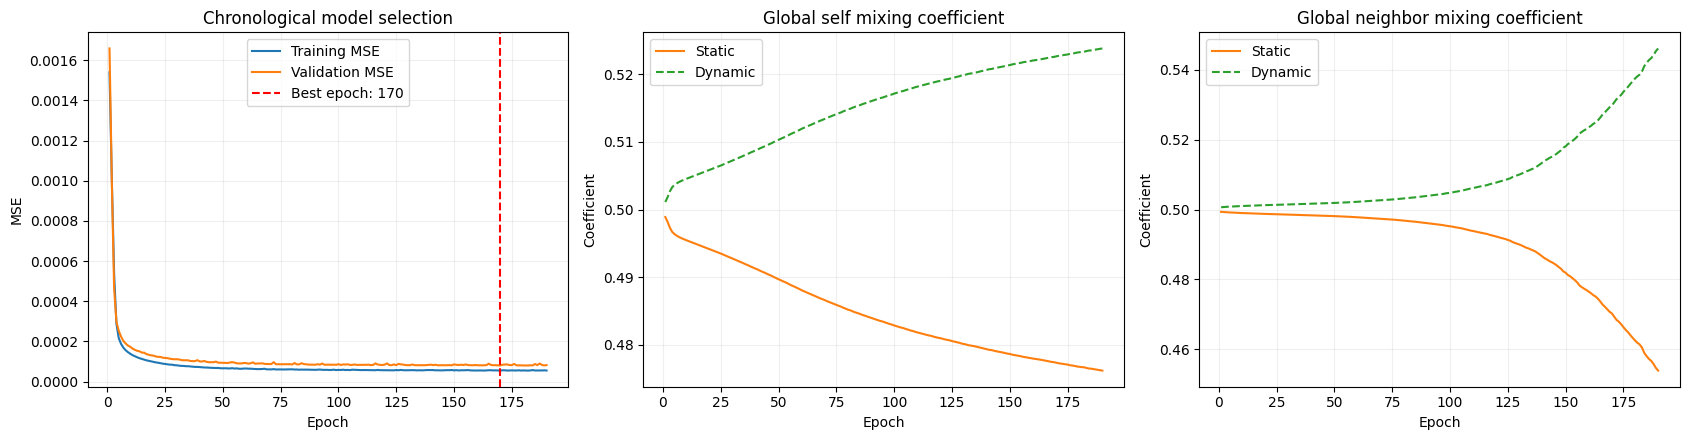

,role,coefficient,within_0_1
0,self,0.477334,True
1,neighbor,0.470273,True


In [34]:
epochs=np.arange(1,len(train_loss_history)+1)
fig,axes=plt.subplots(1,3,figsize=(17,4.5))
axes[0].plot(epochs,train_loss_history,label="Training MSE"); axes[0].plot(epochs,validation_loss_history,label="Validation MSE"); axes[0].axvline(best_epoch,color="red",linestyle="--",label=f"Best epoch: {best_epoch}"); axes[0].set(title="Chronological model selection",xlabel="Epoch",ylabel="MSE"); axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].plot(epochs,alpha_self_history,label="Static",color="tab:orange"); axes[1].plot(epochs,1-np.asarray(alpha_self_history),label="Dynamic",color="tab:green",linestyle="--"); axes[1].set(title="Global self mixing coefficient",xlabel="Epoch",ylabel="Coefficient"); axes[1].legend(); axes[1].grid(alpha=.2)
axes[2].plot(epochs,alpha_neigh_history,label="Static",color="tab:orange"); axes[2].plot(epochs,1-np.asarray(alpha_neigh_history),label="Dynamic",color="tab:green",linestyle="--"); axes[2].set(title="Global neighbor mixing coefficient",xlabel="Epoch",ylabel="Coefficient"); axes[2].legend(); axes[2].grid(alpha=.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_training_validation_coefficients.png"),dpi=300,bbox_inches="tight"); plt.show()

final_self=float(model.gnn.alpha_self.detach().cpu()); final_neighbor=float(model.gnn.alpha_neigh.detach().cpu())
scalar_range_audit=pd.DataFrame([{"role":"self","coefficient":final_self,"within_0_1":0<=final_self<=1},{"role":"neighbor","coefficient":final_neighbor,"within_0_1":0<=final_neighbor<=1}]); display(scalar_range_audit)
if not scalar_range_audit.within_0_1.all(): warnings.warn("At least one scalar left [0,1]. Report it as an unconstrained mixing coefficient, not a probability gate.")


# Complete scalar-M11 explainability suite

## Eligibility relative to the other notebooks

| Analysis | Scalar M11 status |
|---|---|
| Self and neighbor global mixing | Applicable |
| Feature-wise gate specialization | **Not applicable: one scalar per role** |
| Node/time/edge gate variation | **Not applicable: coefficients are global** |
| Gate–crime and gate–error association | **Undefined: zero within-run gate variance** |
| Gate entropy/saturation | Only two scalar diagnostics; no distribution |
| Self-versus-neighbor distinction | Applicable |
| Effective activation contribution | Applicable and essential |
| Fixed coefficient intervention | Applicable |
| Shuffled gate assignment | **Not applicable: no case assignments exist** |
| Input permutation importance | Applicable |
| Graph reliance | Applicable |
| Time-cluster bootstrap | Applicable for predictions/effective activation, not global coefficients |

This distinction is architectural. A constant gate–crime correlation is undefined rather than evidence of no relationship.

## A. Rich node-time collection and effective activation

In [35]:
try:
    from scipy.stats import pearsonr,spearmanr
    SCIPY_AVAILABLE=True
except ImportError: SCIPY_AVAILABLE=False

def _expand_scalar_meta(value,n,fallback,device):
    if value is None: value=torch.as_tensor(fallback,device=device)
    value=value.reshape(-1)
    if value.numel()==1 and n>1: value=value.repeat(n)
    if value.numel()!=n: raise ValueError(f"Metadata length {value.numel()} != {n}")
    return value

@torch.no_grad()
def collect_scalar_explainability(model,loader,device):
    model.eval(); frames=[]; embeddings=[]; predictions_per_time=[]; targets_per_time=[]
    for step,data in enumerate(loader):
        data=data.to(device); prediction,hidden,details=model(data.x_static,data.x_dynamic,data.edge_index,return_details=True); target=data.y.float().view_as(prediction); n=target.numel(); node_ids=_expand_scalar_meta(getattr(data,"node_ids",None),n,torch.arange(n,device=device),device); time_ids=_expand_scalar_meta(getattr(data,"time_id",None),n,step,device)
        ss=torch.linalg.vector_norm(details["static_self_component"],dim=1); ds=torch.linalg.vector_norm(details["dynamic_self_component"],dim=1); sn=torch.linalg.vector_norm(details["static_neighbor_component"],dim=1); dn=torch.linalg.vector_norm(details["dynamic_neighbor_component"],dim=1)
        self_prop=ss/(ss+ds+1e-12); neighbor_prop=sn/(sn+dn+1e-12)
        frames.append(pd.DataFrame({"node_id":node_ids.cpu().numpy(),"time_id":time_ids.cpu().numpy(),"input_crime":data.x_dynamic.mean(dim=1).cpu().numpy(),"target_crime":target.cpu().numpy(),"prediction":prediction.cpu().numpy(),"residual":(target-prediction).cpu().numpy(),"absolute_error":(target-prediction).abs().cpu().numpy(),"self_static_coefficient":float(model.gnn.alpha_self.detach().cpu()),"neighbor_static_coefficient":float(model.gnn.alpha_neigh.detach().cpu()),"self_static_activation":ss.cpu().numpy(),"self_dynamic_activation":ds.cpu().numpy(),"neighbor_static_activation":sn.cpu().numpy(),"neighbor_dynamic_activation":dn.cpu().numpy(),"self_effective_static_proportion":self_prop.cpu().numpy(),"neighbor_effective_static_proportion":neighbor_prop.cpu().numpy()})); embeddings.append(hidden.cpu()); predictions_per_time.append(prediction.cpu().numpy()); targets_per_time.append(target.cpu().numpy())
    frame=pd.concat(frames,ignore_index=True); error=frame.prediction.to_numpy()-frame.target_crime.to_numpy(); target=frame.target_crime.to_numpy(); mse=float(np.mean(error**2)); denom=float(np.sum((target-target.mean())**2)); metrics={"MSE":mse,"RMSE":float(np.sqrt(mse)),"MAE":float(np.mean(np.abs(error))),"R2":float(1-np.sum(error**2)/denom) if denom>0 else np.nan}
    return metrics,{"frame":frame,"embeddings_per_time":embeddings,"predictions_per_time":predictions_per_time,"targets_per_time":targets_per_time}

scalar_metrics,scalar_details=collect_scalar_explainability(model,test_loader,device); scalar_frame=scalar_details["frame"]; preds_per_t=scalar_details["predictions_per_time"]; targets_per_t=scalar_details["targets_per_time"]
display(pd.DataFrame([scalar_metrics])); display(scalar_frame.head()); scalar_frame.to_csv(os.path.join(output_folder,"scalar_m11_rich_explainability.csv"),index=False)


,MSE,RMSE,MAE,R2
0,0.000053,0.007297,0.003791,0.981646


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,self_static_coefficient,neighbor_static_coefficient,self_static_activation,self_dynamic_activation,neighbor_static_activation,neighbor_dynamic_activation,self_effective_static_proportion,neighbor_effective_static_proportion
0,0,100,0.126909,0.136371,0.109535,0.026836,0.026836,0.477334,0.470273,0.867009,0.209107,2.778221,0.419213,0.805683,0.868891
1,1,100,0.109170,0.097192,0.103284,-0.006092,0.006092,0.477334,0.470273,0.758006,0.183457,3.570314,0.517933,0.805136,0.873312
2,2,100,0.161374,0.125887,0.132939,-0.007053,0.007053,0.477334,0.470273,0.844443,0.266348,3.753000,0.428519,0.760217,0.897521
3,3,100,0.096176,0.097884,0.088833,0.009051,0.009051,0.477334,0.470273,0.781934,0.158709,4.359097,0.551955,0.831276,0.887610
4,4,100,0.014133,0.041428,0.045913,-0.004485,0.004485,0.477334,0.470273,0.805961,0.050189,2.594516,0.071267,0.941378,0.973266


## B. Scalar health and effective role comparison

Raw scalar coefficients alone ignore projection and aggregation magnitudes. Effective proportions compare weighted static and dynamic activation norms. They are magnitude diagnostics, not causal importance.

,role,static_coefficient,dynamic_coefficient,binary_entropy_if_valid,mean_effective_static_proportion
0,self,0.47733,0.52267,0.99852,0.94075
1,neighbor,0.47027,0.52973,0.99745,0.94304


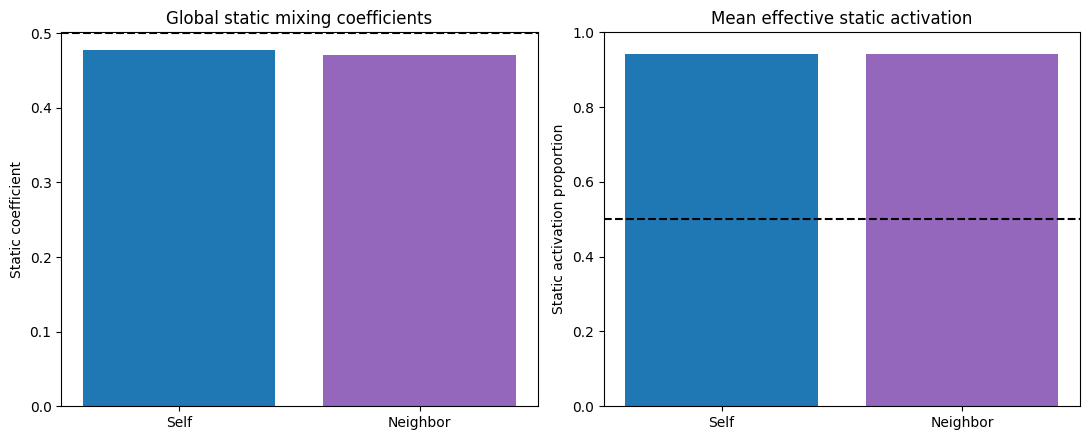

In [36]:
def binary_entropy_scalar(x,eps=1e-8):
    if not 0<=x<=1: return np.nan
    p=np.clip(x,eps,1-eps); return float(-(p*np.log(p)+(1-p)*np.log(1-p))/np.log(2))
scalar_health=pd.DataFrame([{"role":"self","static_coefficient":final_self,"dynamic_coefficient":1-final_self,"binary_entropy_if_valid":binary_entropy_scalar(final_self),"mean_effective_static_proportion":scalar_frame.self_effective_static_proportion.mean()},{"role":"neighbor","static_coefficient":final_neighbor,"dynamic_coefficient":1-final_neighbor,"binary_entropy_if_valid":binary_entropy_scalar(final_neighbor),"mean_effective_static_proportion":scalar_frame.neighbor_effective_static_proportion.mean()}]); display(scalar_health.round(5))
fig,axes=plt.subplots(1,2,figsize=(11,4.5)); axes[0].bar(["Self","Neighbor"],[final_self,final_neighbor],color=["tab:blue","tab:purple"]); axes[0].axhline(.5,color="black",linestyle="--"); axes[0].set(title="Global static mixing coefficients",ylabel="Static coefficient")
axes[1].bar(["Self","Neighbor"],[scalar_frame.self_effective_static_proportion.mean(),scalar_frame.neighbor_effective_static_proportion.mean()],color=["tab:blue","tab:purple"]); axes[1].axhline(.5,color="black",linestyle="--"); axes[1].set(title="Mean effective static activation",ylabel="Static activation proportion",ylim=(0,1)); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_health_effective_roles.png"),dpi=300,bbox_inches="tight"); plt.show(); scalar_health.to_csv(os.path.join(output_folder,"scalar_health.csv"),index=False)


## C. Feature-wise specialization — not applicable

Vector M11 learns one coefficient per latent dimension. Scalar M11 has exactly one coefficient for the entire self representation and one for the entire neighbor representation. Therefore, feature-wise gate means, variances and crime correlations cannot be computed. Channel activation analysis would describe the projection networks, not gate specialization.

## D. Gate–crime, spatial/temporal gate stability and gate–error association — not applicable

Within one fitted model, every node, time and edge receives the same self coefficient and the same neighbor coefficient. Their standard deviations are exactly zero, making correlations with crime or error undefined. Effective activation proportions can still vary because inputs and neighborhood compositions vary; those conditional magnitudes are analyzed below.

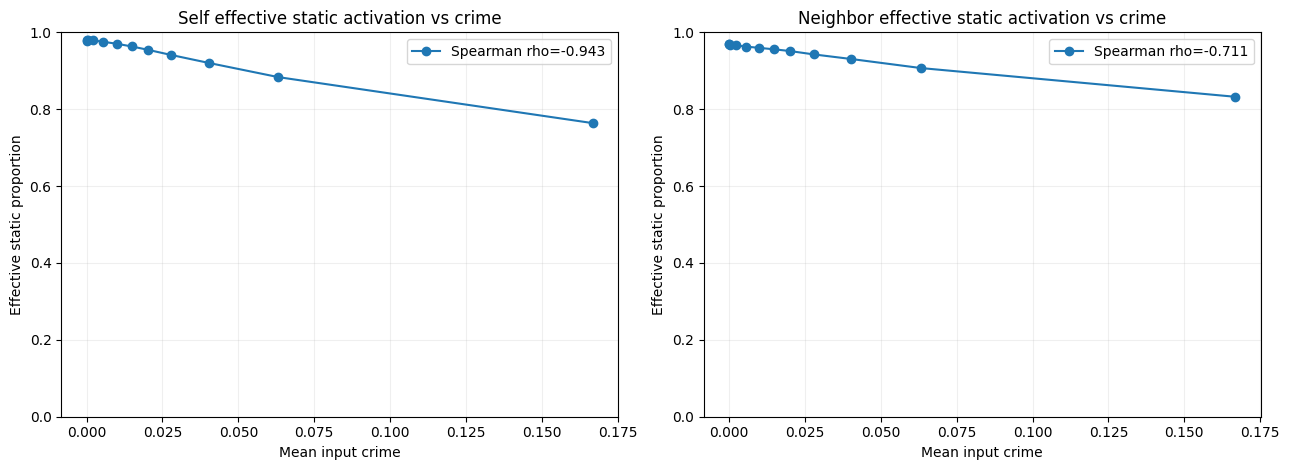

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,Self,-0.82051,0.0,-0.94313,0.0
1,Neighbor,-0.74576,0.0,-0.71087,0.0


In [37]:
def assoc_scalar(x,y):
    x,y=np.asarray(x),np.asarray(y); valid=np.isfinite(x)&np.isfinite(y); x,y=x[valid],y[valid]
    if len(x)<3 or np.std(x)==0 or np.std(y)==0: return {"pearson_r":np.nan,"pearson_p":np.nan,"spearman_rho":np.nan,"spearman_p":np.nan}
    if SCIPY_AVAILABLE:
        p,s=pearsonr(x,y),spearmanr(x,y); return {"pearson_r":float(p[0]),"pearson_p":float(p[1]),"spearman_rho":float(s[0]),"spearman_p":float(s[1])}
    return {"pearson_r":float(np.corrcoef(x,y)[0,1]),"pearson_p":np.nan,"spearman_rho":np.nan,"spearman_p":np.nan}
def binned_scalar(frame,x,y,bins=12):
    w=frame[[x,y]].replace([np.inf,-np.inf],np.nan).dropna().copy(); w["bin"]=pd.qcut(w[x],q=bins,duplicates="drop"); o=w.groupby("bin",observed=True).agg(mean_x=(x,"mean"),mean_y=(y,"mean"),std_y=(y,"std"),count=(y,"size")).reset_index(drop=True); o["ci95"]=1.96*o.std_y/np.sqrt(o["count"].clip(lower=1)); return o
rows=[]; fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,(role,col) in zip(axes,[("Self","self_effective_static_proportion"),("Neighbor","neighbor_effective_static_proportion")]):
    stats=assoc_scalar(scalar_frame.input_crime,scalar_frame[col]); rows.append({"role":role,**stats}); summary=binned_scalar(scalar_frame,"input_crime",col); ax.plot(summary.mean_x,summary.mean_y,marker="o"); ax.fill_between(summary.mean_x,summary.mean_y-summary.ci95,summary.mean_y+summary.ci95,alpha=.2); ax.set(title=f"{role} effective static activation vs crime",xlabel="Mean input crime",ylabel="Effective static proportion",ylim=(0,1)); ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"]); ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_effective_activation_crime.png"),dpi=300,bbox_inches="tight"); plt.show(); scalar_effective_crime_associations=pd.DataFrame(rows); display(scalar_effective_crime_associations.round(5))


## E. Spatial and temporal stability of effective activation

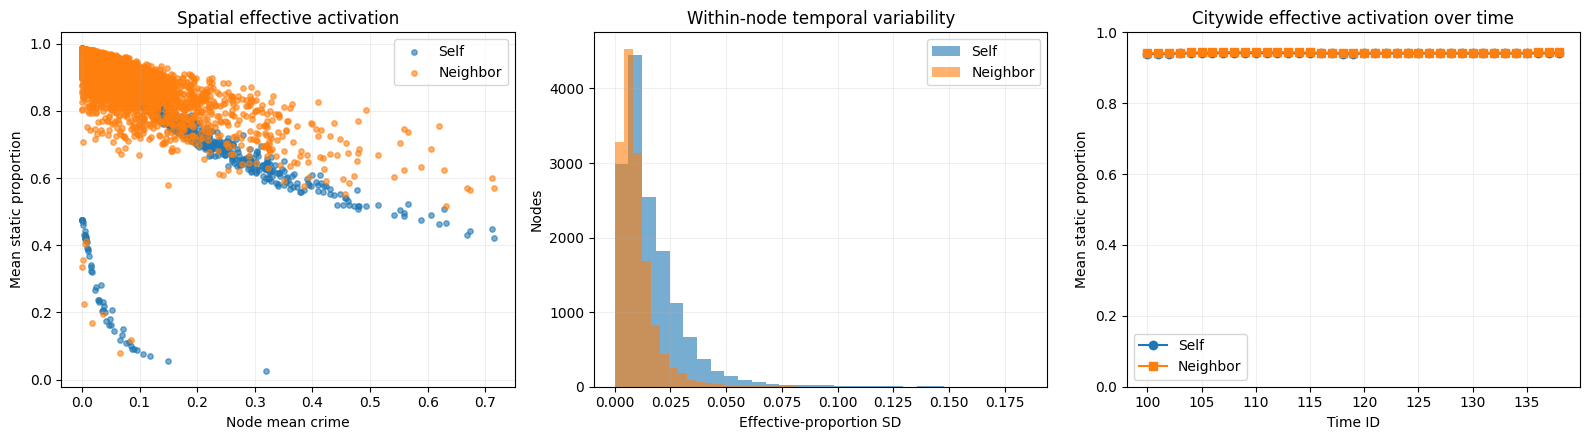

In [38]:
node_eff=scalar_frame.groupby("node_id").agg(self_static_mean=("self_effective_static_proportion","mean"),self_static_std=("self_effective_static_proportion","std"),neighbor_static_mean=("neighbor_effective_static_proportion","mean"),neighbor_static_std=("neighbor_effective_static_proportion","std"),mean_crime=("input_crime","mean"),mean_absolute_error=("absolute_error","mean")).reset_index(); time_eff=scalar_frame.groupby("time_id").agg(self_static_mean=("self_effective_static_proportion","mean"),neighbor_static_mean=("neighbor_effective_static_proportion","mean"),mean_crime=("input_crime","mean")).reset_index()
fig,axes=plt.subplots(1,3,figsize=(16,4.5)); axes[0].scatter(node_eff.mean_crime,node_eff.self_static_mean,s=15,alpha=.6,label="Self"); axes[0].scatter(node_eff.mean_crime,node_eff.neighbor_static_mean,s=15,alpha=.6,label="Neighbor"); axes[0].set(title="Spatial effective activation",xlabel="Node mean crime",ylabel="Mean static proportion"); axes[0].legend()
axes[1].hist(node_eff.self_static_std.dropna(),bins=30,alpha=.6,label="Self"); axes[1].hist(node_eff.neighbor_static_std.dropna(),bins=30,alpha=.6,label="Neighbor"); axes[1].set(title="Within-node temporal variability",xlabel="Effective-proportion SD",ylabel="Nodes"); axes[1].legend()
axes[2].plot(time_eff.time_id,time_eff.self_static_mean,marker="o",label="Self"); axes[2].plot(time_eff.time_id,time_eff.neighbor_static_mean,marker="s",label="Neighbor"); axes[2].set(title="Citywide effective activation over time",xlabel="Time ID",ylabel="Mean static proportion",ylim=(0,1)); axes[2].legend()
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_effective_spatial_temporal.png"),dpi=300,bbox_inches="tight"); plt.show(); node_eff.to_csv(os.path.join(output_folder,"scalar_node_effective_stability.csv"),index=False); time_eff.to_csv(os.path.join(output_folder,"scalar_time_effective_stability.csv"),index=False)


## F. Fixed scalar interventions

All weights remain fixed while the two global coefficients are replaced. Unlike vector M11, shuffled-gate intervention is impossible because scalar M11 has no node/time/feature assignments to shuffle.

,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned scalars,0.000053,0.007297,0.003791,0.0,0.0
1,Both balanced,0.000053,0.007297,0.003791,0.0,0.0
2,Both static-only,0.000053,0.007297,0.003791,0.0,0.0
3,Both dynamic-only,0.000053,0.007297,0.003791,0.0,0.0
4,Self static / neighbor dynamic,0.000053,0.007297,0.003791,0.0,0.0
5,Self dynamic / neighbor static,0.000053,0.007297,0.003791,0.0,0.0
6,Swap learned roles,0.000053,0.007297,0.003791,0.0,0.0


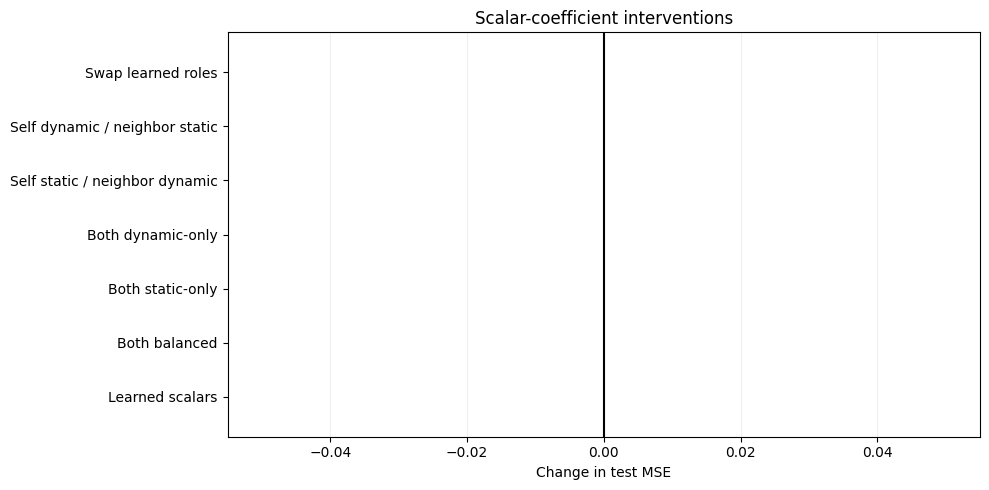

In [39]:
@torch.no_grad()
def evaluate_scalar_current(model,loader,device):
    model.eval(); preds=[]; targets=[]
    for data in loader:
        data=data.to(device); prediction,_=model(data.x_static,data.x_dynamic,data.edge_index); preds.append(prediction.cpu()); targets.append(data.y.float().view_as(prediction).cpu())
    prediction=torch.cat(preds).numpy(); target=torch.cat(targets).numpy(); error=prediction-target; mse=float(np.mean(error**2)); return {"MSE":mse,"RMSE":float(np.sqrt(mse)),"MAE":float(np.mean(np.abs(error)))}

original_self=model.gnn.alpha_self.detach().clone(); original_neighbor=model.gnn.alpha_neigh.detach().clone(); specs=[("Learned scalars",None,None),("Both balanced",.5,.5),("Both static-only",1.,1.),("Both dynamic-only",0.,0.),("Self static / neighbor dynamic",1.,0.),("Self dynamic / neighbor static",0.,1.),("Swap learned roles",float(original_neighbor.cpu()),float(original_self.cpu()))]; rows=[]
try:
    for label,a_self,a_neigh in specs:
        if a_self is not None:
            model.gnn.alpha_self.data.fill_(a_self); model.gnn.alpha_neigh.data.fill_(a_neigh)
        rows.append({"intervention":label,**evaluate_scalar_current(model,test_loader,device)})
finally:
    model.gnn.alpha_self.data.copy_(original_self); model.gnn.alpha_neigh.data.copy_(original_neighbor)
scalar_interventions=pd.DataFrame(rows); base=scalar_interventions.loc[scalar_interventions.intervention=="Learned scalars","MSE"].iloc[0]; scalar_interventions["delta_MSE_vs_learned"]=scalar_interventions.MSE-base; scalar_interventions["relative_MSE_change_percent"]=100*scalar_interventions.delta_MSE_vs_learned/(base+1e-12); display(scalar_interventions.round(6)); plot_df=scalar_interventions.sort_values("delta_MSE_vs_learned"); plt.figure(figsize=(10,5)); plt.barh(plot_df.intervention,plot_df.delta_MSE_vs_learned,color=["tab:green" if x<=0 else "tab:red" for x in plot_df.delta_MSE_vs_learned]); plt.axvline(0,color="black"); plt.xlabel("Change in test MSE"); plt.title("Scalar-coefficient interventions"); plt.grid(axis="x",alpha=.2); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_interventions.png"),dpi=300,bbox_inches="tight"); plt.show(); scalar_interventions.to_csv(os.path.join(output_folder,"scalar_interventions.csv"),index=False)


## G. Original-feature permutation importance

,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.000053,0.005837,8.401564e-06,0.005784
14,dynamic,crime_lag_2,0.000053,0.000083,1.407731e-07,0.000030
1,static,Renda_media_responsaveis,0.000053,0.000080,3.708526e-08,0.000026
0,static,Renda_media_por_domicilio,0.000053,0.000078,1.541608e-07,0.000025
10,static,Favela_proxima,0.000053,0.000062,8.639531e-08,0.000009
13,dynamic,crime_lag_3,0.000053,0.000059,4.879802e-08,0.000006
9,static,Terminal_de_onibus,0.000053,0.000059,8.702740e-08,0.000005
12,dynamic,crime_lag_4,0.000053,0.000058,6.406692e-08,0.000005
8,static,Estacao_de_trem,0.000053,0.000058,2.907856e-08,0.000005
11,dynamic,crime_lag_5,0.000053,0.000058,3.176034e-08,0.000004


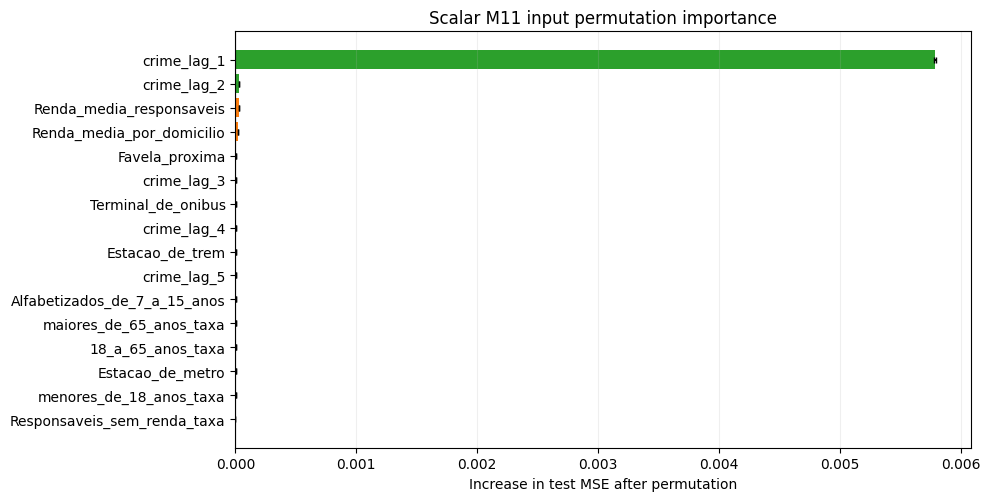

In [40]:
@torch.no_grad()
def scalar_permutation_importance(model,loader,device,static_names=None,repeats=3,random_seed=42):
    model.eval(); baseline=scalar_metrics["MSE"]; sample=next(iter(loader)); sd=sample.x_static.shape[1]; dd=sample.x_dynamic.shape[1]
    if static_names is None or len(static_names)!=sd: static_names=[f"static_{i}" for i in range(sd)]
    dynamic_names=[f"crime_lag_{dd-i}" for i in range(dd)]; rows=[]
    for modality,dim,names in [("static",sd,static_names),("dynamic",dd,dynamic_names)]:
        for fi in range(dim):
            losses=[]
            for repeat in range(repeats):
                pa=[]; ta=[]
                for step,data in enumerate(loader):
                    data=data.to(device); xs=data.x_static.clone(); xd=data.x_dynamic.clone(); g=torch.Generator(device=device); g.manual_seed(random_seed+100000*(modality=="dynamic")+1000*fi+31*repeat+step); perm=torch.randperm(xs.shape[0],generator=g,device=device)
                    if modality=="static": xs[:,fi]=xs[perm,fi]
                    else: xd[:,fi]=xd[perm,fi]
                    pred,_=model(xs,xd,data.edge_index); pa.append(pred.cpu()); ta.append(data.y.float().view_as(pred).cpu())
                pred=torch.cat(pa).numpy(); target=torch.cat(ta).numpy(); losses.append(float(np.mean((pred-target)**2)))
            rows.append({"modality":modality,"feature":names[fi],"baseline_MSE":baseline,"permuted_MSE_mean":np.mean(losses),"permuted_MSE_std":np.std(losses,ddof=1) if repeats>1 else 0,"delta_MSE":np.mean(losses)-baseline})
    return pd.DataFrame(rows)
static_names=list(static_dt.columns) if len(static_dt.columns)==S else None; scalar_permutation_table=scalar_permutation_importance(model,test_loader,device,static_names,3,seed); display(scalar_permutation_table.sort_values("delta_MSE",ascending=False).head(15)); plot_df=scalar_permutation_table.sort_values("delta_MSE"); plt.figure(figsize=(10,max(5,.32*len(plot_df)))); plt.barh(plot_df.feature,plot_df.delta_MSE,xerr=plot_df.permuted_MSE_std,color=plot_df.modality.map({"static":"tab:orange","dynamic":"tab:green"}),capsize=2); plt.axvline(0,color="black"); plt.xlabel("Increase in test MSE after permutation"); plt.title("Scalar M11 input permutation importance"); plt.grid(axis="x",alpha=.2); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_input_permutation.png"),dpi=300,bbox_inches="tight"); plt.show(); scalar_permutation_table.to_csv(os.path.join(output_folder,"scalar_input_permutation.csv"),index=False)


## H. Graph reliance, prediction diagnostics and embedding

,condition,MSE,RMSE,MAE,delta_MSE_vs_graph
0,Learned graph,0.000053,0.007297,0.003791,0.00000
1,Neighbor edges removed,0.000704,0.026527,0.016192,0.00065


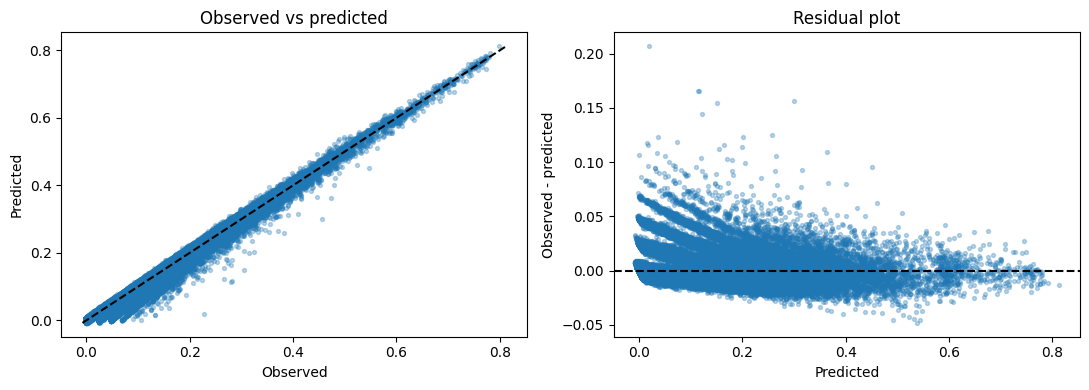

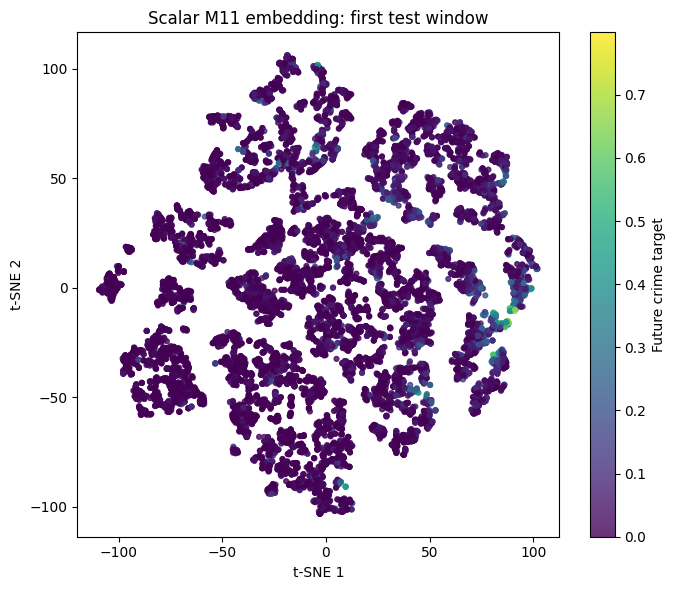

In [41]:
@torch.no_grad()
def scalar_edge_evaluation(model,loader,device,remove_edges=False):
    model.eval(); pa=[]; ta=[]
    for data in loader:
        data=data.to(device); edges=data.edge_index if not remove_edges else torch.empty((2,0),dtype=torch.long,device=device); pred,_=model(data.x_static,data.x_dynamic,edges); pa.append(pred.cpu()); ta.append(data.y.float().view_as(pred).cpu())
    pred=torch.cat(pa).numpy(); target=torch.cat(ta).numpy(); error=pred-target; mse=float(np.mean(error**2)); return {"MSE":mse,"RMSE":float(np.sqrt(mse)),"MAE":float(np.mean(np.abs(error)))}
scalar_graph_intervention=pd.DataFrame([{"condition":"Learned graph",**scalar_edge_evaluation(model,test_loader,device,False)},{"condition":"Neighbor edges removed",**scalar_edge_evaluation(model,test_loader,device,True)}]); base=scalar_graph_intervention.loc[0,"MSE"]; scalar_graph_intervention["delta_MSE_vs_graph"]=scalar_graph_intervention.MSE-base; display(scalar_graph_intervention.round(6)); scalar_graph_intervention.to_csv(os.path.join(output_folder,"scalar_graph_intervention.csv"),index=False)

pred_matrix=np.stack(preds_per_t); target_matrix=np.stack(targets_per_t); y_pred=pred_matrix.reshape(-1); y_true=target_matrix.reshape(-1); residual=y_true-y_pred
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].scatter(y_true,y_pred,s=8,alpha=.3); lo=min(y_true.min(),y_pred.min()); hi=max(y_true.max(),y_pred.max()); axes[0].plot([lo,hi],[lo,hi],color="black",linestyle="--"); axes[0].set(title="Observed vs predicted",xlabel="Observed",ylabel="Predicted"); axes[1].scatter(y_pred,residual,s=8,alpha=.3); axes[1].axhline(0,color="black",linestyle="--"); axes[1].set(title="Residual plot",xlabel="Predicted",ylabel="Observed - predicted"); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_prediction_diagnostics.png"),dpi=300,bbox_inches="tight"); plt.show()

from sklearn.manifold import TSNE
embedding=scalar_details["embeddings_per_time"][0].numpy(); target_first=targets_per_t[0]; perplexity=min(30,max(2,(embedding.shape[0]-1)//3)); emb2d=TSNE(n_components=2,perplexity=perplexity,init="pca",learning_rate="auto",random_state=seed).fit_transform(embedding); plt.figure(figsize=(7,6)); sc=plt.scatter(emb2d[:,0],emb2d[:,1],c=target_first,cmap="viridis",s=12,alpha=.8); plt.colorbar(sc,label="Future crime target"); plt.title("Scalar M11 embedding: first test window"); plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_embedding_tsne.png"),dpi=300,bbox_inches="tight"); plt.show()


## I. Input-gradient sensitivity and effective activation versus error

Gradient sensitivity measures how strongly the current prediction responds locally to each input modality. It is scale-dependent and should be interpreted together with ablation and permutation importance. Effective activation–error association describes difficult cases; it is not causal.

,static_mean_abs_gradient,dynamic_mean_abs_gradient,static_normalized_gradient,dynamic_normalized_gradient
0,0.000001,0.000016,0.059633,0.940367


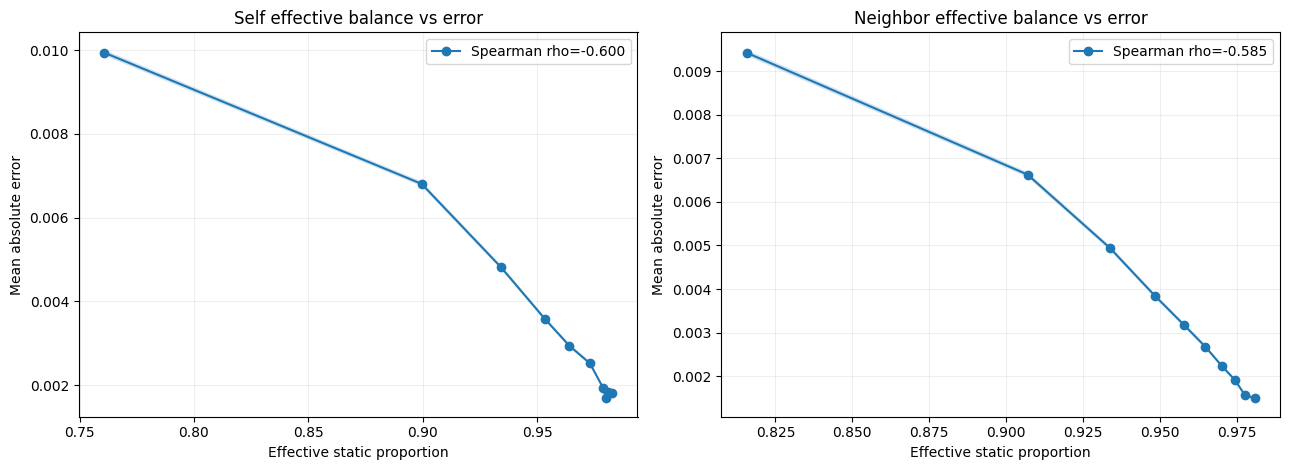

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,Self,-0.33329,0.0,-0.60028,0.0
1,Neighbor,-0.35333,0.0,-0.58494,0.0


In [42]:
def scalar_gradient_sensitivity(model,data,device):
    model.eval(); data=data.to(device); xs=data.x_static.detach().clone().requires_grad_(True); xd=data.x_dynamic.detach().clone().requires_grad_(True); prediction,_=model(xs,xd,data.edge_index); prediction.mean().backward(); gs=xs.grad.abs().mean().item(); gd=xd.grad.abs().mean().item(); total=gs+gd+1e-12; return {"static_mean_abs_gradient":gs,"dynamic_mean_abs_gradient":gd,"static_normalized_gradient":gs/total,"dynamic_normalized_gradient":gd/total}
scalar_gradient_results=scalar_gradient_sensitivity(model,next(iter(test_loader)),device); display(pd.DataFrame([scalar_gradient_results]).round(6))

error_rows=[]; fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,(role,col) in zip(axes,[("Self","self_effective_static_proportion"),("Neighbor","neighbor_effective_static_proportion")]):
    stats=assoc_scalar(scalar_frame[col],scalar_frame.absolute_error); error_rows.append({"role":role,**stats}); summary=binned_scalar(scalar_frame,col,"absolute_error",10); ax.plot(summary.mean_x,summary.mean_y,marker="o"); ax.fill_between(summary.mean_x,summary.mean_y-summary.ci95,summary.mean_y+summary.ci95,alpha=.2); ax.set(title=f"{role} effective balance vs error",xlabel="Effective static proportion",ylabel="Mean absolute error"); ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"]); ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_effective_balance_error.png"),dpi=300,bbox_inches="tight"); plt.show(); scalar_effective_error_associations=pd.DataFrame(error_rows); display(scalar_effective_error_associations.round(5))


## J. Exact-hop neighborhood prediction context

The model explicitly aggregates neighbors, so exact-hop prediction curves are applicable. They visualize spatial context but do not isolate the learned neighbor coefficient; edge intervention provides stronger functional evidence.

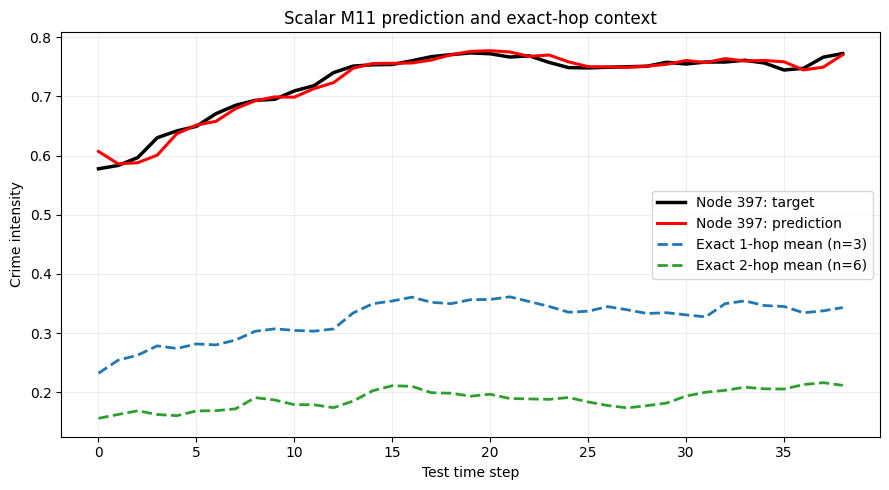

In [43]:
def scalar_adjacency(edge_index,num_nodes):
    adjacency={i:set() for i in range(num_nodes)}; src,dst=edge_index.detach().cpu().numpy()
    for u,v in zip(src,dst): adjacency[int(u)].add(int(v)); adjacency[int(v)].add(int(u))
    return adjacency
def scalar_exact_hop(center,adjacency,hop):
    visited={center}; frontier={center}
    for _ in range(hop):
        nxt=set()
        for node in frontier: nxt.update(adjacency.get(node,set()))
        nxt-=visited; visited|=nxt; frontier=nxt
    return sorted(frontier)
sample_graph=test_dataset[0]; adjacency=scalar_adjacency(sample_graph.edge_index,pred_matrix.shape[1]); selected_node=int(np.argmax(target_matrix.mean(axis=0))); time=np.arange(pred_matrix.shape[0]); plt.figure(figsize=(9,5)); plt.plot(time,target_matrix[:,selected_node],color="black",linewidth=2.5,label=f"Node {selected_node}: target"); plt.plot(time,pred_matrix[:,selected_node],color="red",linewidth=2.2,label=f"Node {selected_node}: prediction")
for hop,color in zip([1,2],["tab:blue","tab:green"]):
    nodes=scalar_exact_hop(selected_node,adjacency,hop)
    if nodes: plt.plot(time,pred_matrix[:,nodes].mean(axis=1),linestyle="--",linewidth=2,color=color,label=f"Exact {hop}-hop mean (n={len(nodes)})")
plt.xlabel("Test time step"); plt.ylabel("Crime intensity"); plt.title("Scalar M11 prediction and exact-hop context"); plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.savefig(os.path.join(output_folder,"scalar_exact_hop_context.png"),dpi=300,bbox_inches="tight"); plt.show()


## K. Time-cluster bootstrap

Global coefficients are fixed within the fitted model, so bootstrapping them would always reproduce the same two numbers. The bootstrap instead quantifies test-window uncertainty for prediction and effective activation.

In [44]:
def scalar_cluster_bootstrap(frame,n_bootstrap=1000,random_seed=42):
    rng=np.random.default_rng(random_seed); clusters=frame.time_id.drop_duplicates().to_numpy(); estimates=[]
    for _ in range(n_bootstrap):
        sampled=rng.choice(clusters,size=len(clusters),replace=True); boot=pd.concat([frame.loc[frame.time_id==c] for c in sampled],ignore_index=True); error=boot.prediction-boot.target_crime; estimates.append({"MSE":np.mean(error**2),"MAE":np.mean(np.abs(error)),"self_effective_static":boot.self_effective_static_proportion.mean(),"neighbor_effective_static":boot.neighbor_effective_static_proportion.mean()})
    samples=pd.DataFrame(estimates); point={"MSE":scalar_metrics["MSE"],"MAE":scalar_metrics["MAE"],"self_effective_static":frame.self_effective_static_proportion.mean(),"neighbor_effective_static":frame.neighbor_effective_static_proportion.mean()}; summary=pd.DataFrame([{"quantity":c,"estimate":point[c],"bootstrap_ci95_low":samples[c].quantile(.025),"bootstrap_ci95_high":samples[c].quantile(.975),"bootstrap_std":samples[c].std(ddof=1)} for c in samples.columns]); return summary,samples
scalar_bootstrap_summary,scalar_bootstrap_samples=scalar_cluster_bootstrap(scalar_frame,1000,seed); display(scalar_bootstrap_summary.round(6)); scalar_bootstrap_summary.to_csv(os.path.join(output_folder,"scalar_bootstrap_ci.csv"),index=False)


,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,MSE,0.000053,0.000051,0.000055,0.000001
1,MAE,0.003791,0.003749,0.003837,0.000023
2,self_effective_static,0.940750,0.940534,0.940970,0.000112
3,neighbor_effective_static,0.943044,0.942813,0.943280,0.000122


## L. Exportable cross-model summary

In [45]:
learned=scalar_interventions.query("intervention == 'Learned scalars'").iloc[0]; balanced=scalar_interventions.query("intervention == 'Both balanced'").iloc[0]; edges_removed=scalar_graph_intervention.query("condition == 'Neighbor edges removed'").iloc[0]
scalar_model_summary=pd.DataFrame([{"model":"M11 scalar global gates","uses_graph":True,"gate_type":"two_global_unconstrained_scalars","test_MSE":scalar_metrics["MSE"],"test_RMSE":scalar_metrics["RMSE"],"test_MAE":scalar_metrics["MAE"],"test_R2":scalar_metrics["R2"],"self_static_coefficient":final_self,"neighbor_static_coefficient":final_neighbor,"self_effective_static_proportion":scalar_frame.self_effective_static_proportion.mean(),"neighbor_effective_static_proportion":scalar_frame.neighbor_effective_static_proportion.mean(),"balanced_both_delta_MSE":balanced["MSE"]-learned["MSE"],"edges_removed_delta_MSE":edges_removed["MSE"]-scalar_metrics["MSE"],"featurewise_gate_analysis_available":False,"conditional_gate_analysis_available":False,"self_neighbor_role_analysis_available":True,"shuffled_gate_assignment_available":False}]); display(scalar_model_summary.T); scalar_model_summary.to_csv(os.path.join(output_folder,"scalar_m11_professional_summary.csv"),index=False)


,0
model,M11 scalar global gates
uses_graph,True
gate_type,two_global_unconstrained_scalars
test_MSE,0.000053
test_RMSE,0.007297
test_MAE,0.003791
test_R2,0.981646
self_static_coefficient,0.477334
neighbor_static_coefficient,0.470273
self_effective_static_proportion,0.94075


## Interpretation framework

1. Compare prediction metrics across matched chronological splits and seeds.
2. Verify whether both direct scalar coefficients remain in $[0,1]$ before calling them gates.
3. Separate raw scalar values from effective activation magnitudes; projection and neighborhood aggregation can strongly change actual balance.
4. Self-versus-neighbor role comparison is valid because two different global coefficients exist.
5. Feature-wise and conditional gate behavior are unavailable by design, unlike vector M11.
6. Shuffled-gate faithfulness is unavailable because there are no case-specific assignments.
7. Use fixed scalar interventions, input permutation and edge removal for functional evidence.
8. Bootstrap test windows for prediction/effective activation, and use 5–10 matched training seeds for coefficient and performance uncertainty.